# Deutsch-Jozsa Algorithmus
The Deutsch-Jozsa algorithm is a quantum algorithm proposed in 1992 that determines whether an oracle function is constant or balanced with only one query, whereas classical deterministic algorithms require multiple queries `2^(n-1) + 1`.

In [5]:
# Import Qiskit
# pylatexenc -> Circuito
!pip -q install qiskit qiskit-aer pylatexenc

In [6]:
!pip install qiskit qiskit-aer

Defaulting to user installation because normal site-packages is not writeable


In [7]:
# importar o circuito e compilador (transpile - adapter o circuito para compilar no hardware)
!pip install qiskit
from qiskit import QuantumCircuit, transpile
# Simulador local da IBM
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram


Defaulting to user installation because normal site-packages is not writeable


In [8]:
import sys
!{sys.executable} -m pip install qiskit qiskit-aer

# Constant Function

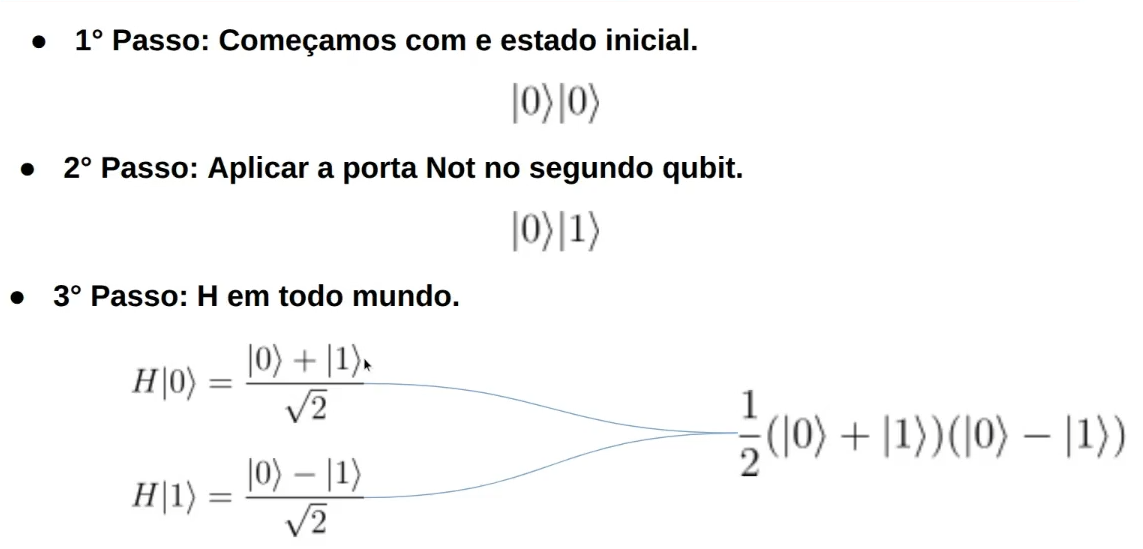

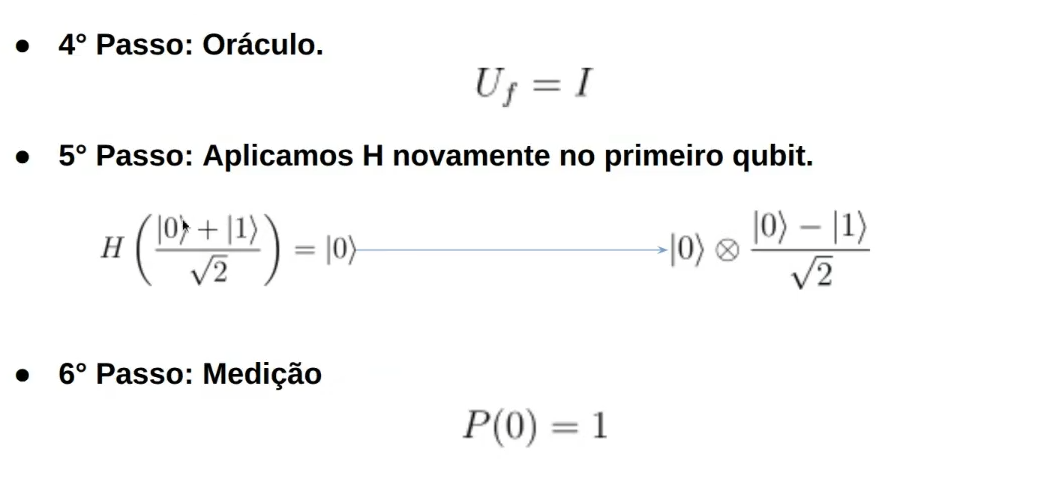

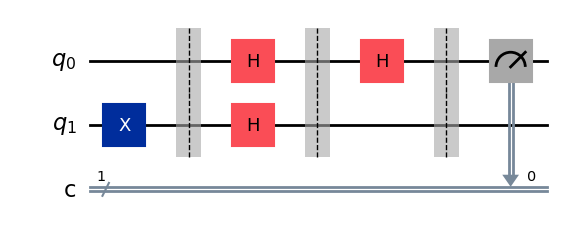

In [19]:
# ------------- Constant Function -------------
#1) Create Circuit

qc_const = QuantumCircuit(2,1)

# 2 Qubits
# 1 Classic bit
#q_0 enter qubit
#q_1 aux qubit

# 2) Prepare State (constant function)

qc_const.x(1)
qc_const.barrier()

# Aux qubit in state |1>

# 3) Hadamard

qc_const.h(0)
qc_const.h(1)
qc_const.barrier()

#UF = id Oracle constant function (do nothing - constant function)
#4) Hadamard in the end of enter qubit
qc_const.h(0)
qc_const.barrier()
#5) Measurements
qc_const.measure(0,0)

#Build Circuit
qc_const.draw("mpl")

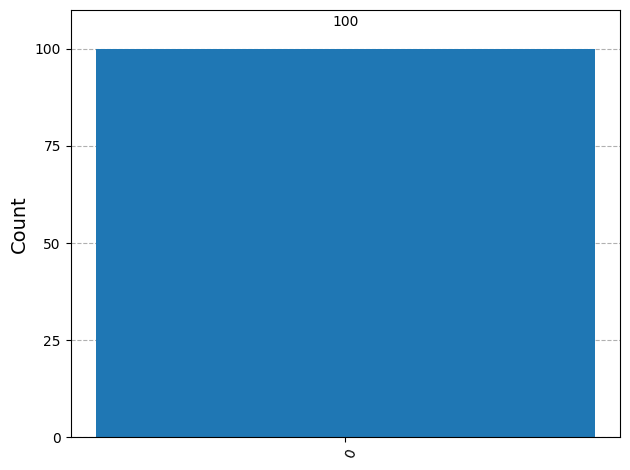

In [36]:
# Simulator - Quantum Hardware
sim = AerSimulator()

# Transpile => convert algorithms to a compatible and optimization version
qc_const_t = transpile(qc_const, sim)

#Shot => measurement
result_const = sim.run(qc_const_t, shots = 1024).result()

#extract in dict format {'0':1024, '1':0}
counts_const = result_const.get_counts()

# Probabilit histogram (classical bit)
plot_histogram(counts_const)

# Balanced Function
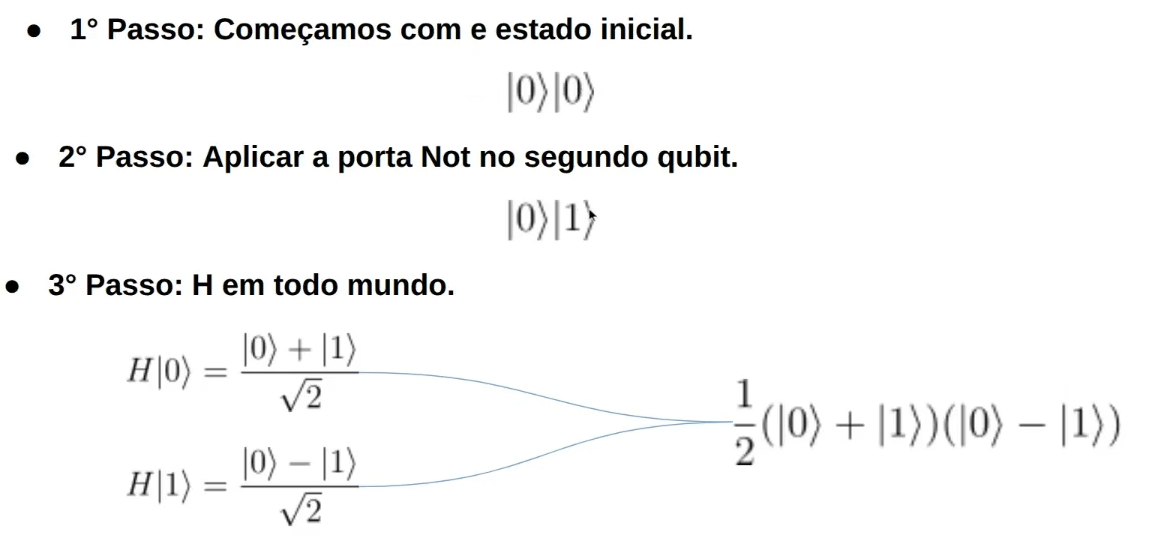

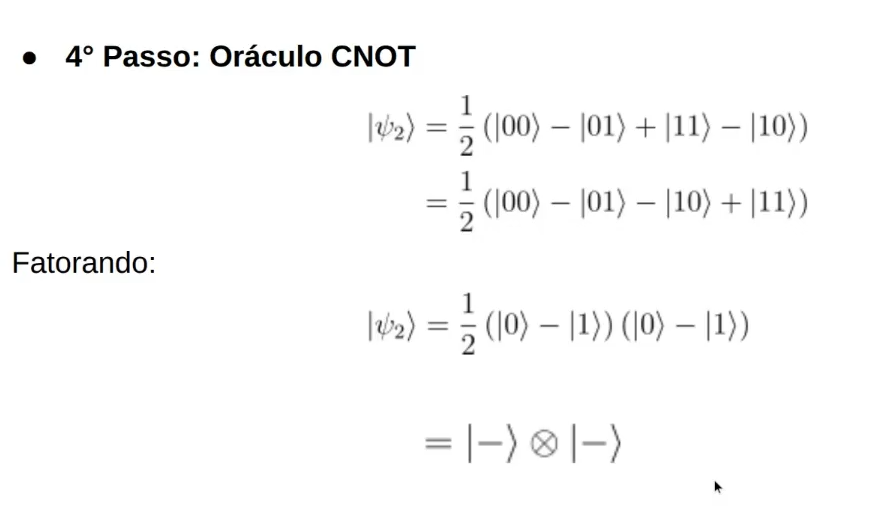

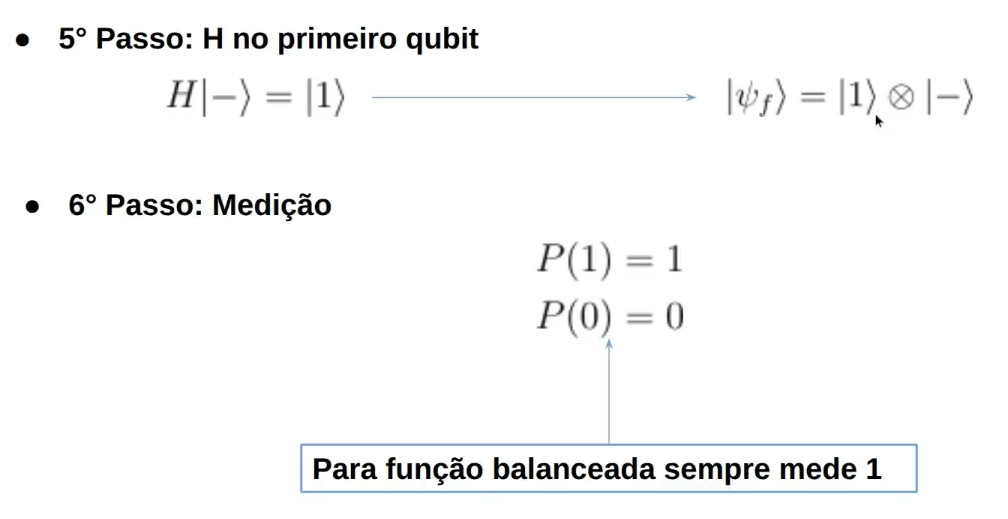

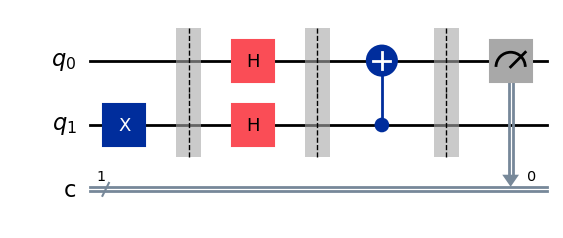

In [26]:
# ------------- Balanced Function -------------
#1) Create Circuit

qc_bl = QuantumCircuit(2,1)

# 2 Qubits
# 1 Classic bit
#q_0 enter qubit
#q_1 aux qubit

# 2) Prepare State
qc_bl.x(1)
qc_bl.barrier()

# Aux qubit in state |1>

# 3) Hadamard

qc_bl.h(0)
qc_bl.h(1)
qc_bl.barrier()

#UF = id Oracle constant function (CNOT)
#4) Hadamard in the end of enter qubit
qc_bl.cx(1,0)
qc_bl.barrier()
#5) Measurements
qc_bl.measure(0,0)

#Build Circuit
qc_bl.draw("mpl")

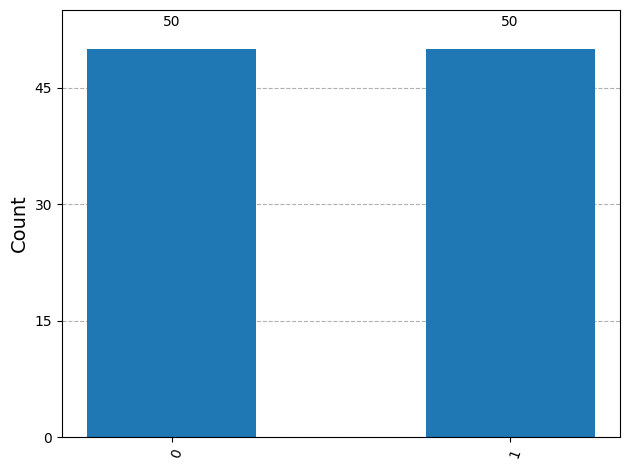

In [37]:
# Simulator - Quantum Hardware
sim = AerSimulator()

# Transpile => convert algorithms to a compatible and optimization version
qc_bl_t = transpile(qc_bl, sim)

#Shot => measurement
result_bl = sim.run(qc_bl_t, shots = 100).result()

#extract in dict format {'0':100, '1':0}
counts_bl = result_bl.get_counts()

# Probabilit histogram (classical bit)
plot_histogram(counts_bl)